In [ ]:
# ============================================
# HEALTHCARE ANALYTICS FOR DOCTOR VISITS
# STEP 1: Import Libraries & Load Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# CSV file load kara
df = pd.read_csv('/content/Healthcare_Analytics_for_Doctor_Visits.csv')

print("✅ Data Loaded Successfully!")
print("Shape (Rows, Columns):", df.shape)
df.head()

✅ Data Loaded Successfully!
Shape (Rows, Columns): (5190, 13)


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [ ]:
# ============================================
# STEP 2: Data Exploration
# ============================================

# Last 5 rows
print("Last 5 Rows:")
df.tail()

# Dataset shape
print("Shape of Dataset:", df.shape)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])


# Dataset info (data types, non-null counts)
df.info()


# Statistical summary
df.describe()


# Check for missing/null values
print("Missing Values in Each Column:")
print(df.isnull().sum())
print("\nTotal Missing Values:", df.isnull().sum().sum())


# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Last 5 Rows:
Shape of Dataset: (5190, 13)
Total Rows: 5190
Total Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB
Missing Values in Each Column:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced   

In [ ]:
# ============================================
# STEP 3: Data Cleaning
# ============================================

# Original data cha copy banवा (safe side sathi)
df_clean = df.copy()

# Unnecessary index column asel tar kadha
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

print("✅ Columns after cleaning:")
print(df_clean.columns.tolist())


# Categorical (yes/no) columns la 0/1 madhe convert kara
categorical_cols = ['private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

for col in categorical_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

print("✅ Categorical columns encoded (yes=1, no=0)")
df_clean[categorical_cols].head()


# Gender column encode kara (male=1, female=0)
df_clean['gender_encoded'] = df_clean['gender'].map({'male': 1, 'female': 0})

print("✅ Gender encoded")
df_clean[['gender', 'gender_encoded']].head()

# Final check - cleaned data cha summary
print("=" * 50)
print("CLEANED DATASET SUMMARY")
print("=" * 50)
print(f"Total Records: {len(df_clean)}")
print(f"Total Columns: {len(df_clean.columns)}")
print(f"Missing Values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate Rows: {df_clean.duplicated().sum()}")

df_clean.head()

✅ Columns after cleaning:
['visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']
✅ Categorical columns encoded (yes=1, no=0)
✅ Gender encoded
CLEANED DATASET SUMMARY
Total Records: 5190
Total Columns: 13
Missing Values: 0
Duplicate Rows: 1320


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,gender_encoded
0,1,female,0.19,0.55,1,4,1,1,0,0,0,0,0
1,1,female,0.19,0.45,1,2,1,1,0,0,0,0,0
2,1,male,0.19,0.90,3,0,0,0,0,0,0,0,1
3,1,male,0.19,0.15,1,0,0,0,0,0,0,0,1
4,1,male,0.19,0.45,2,5,1,0,0,0,1,0,1


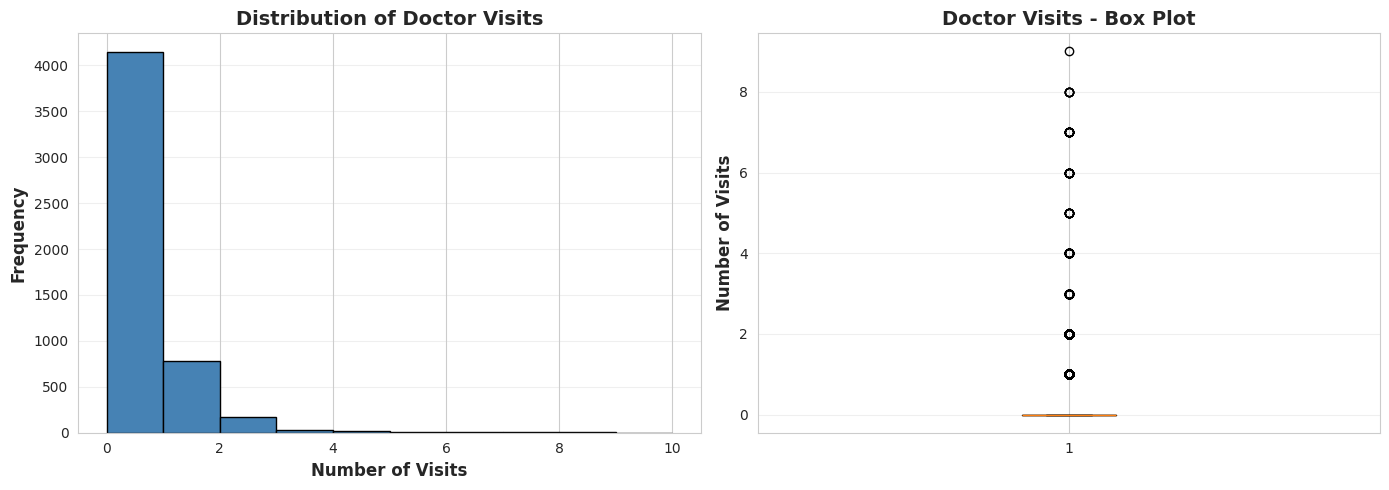

Mean visits: 0.30
Median visits: 0.00
Max visits: 9


In [17]:
# ============================================
# STEP 4: CHART 1 - Doctor Visits Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['visits'], bins=range(int(df_clean['visits'].max()) + 2),
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Visits', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Doctor Visits', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot(df_clean['visits'], vert=True)
axes[1].set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
axes[1].set_title('Doctor Visits - Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_visits_distribution.png', dpi=300, bbox_inches='tight')   # 👈 NAVIN LINE
plt.show()

print(f"Mean visits: {df_clean['visits'].mean():.2f}")
print(f"Median visits: {df_clean['visits'].median():.2f}")
print(f"Max visits: {df_clean['visits'].max()}")

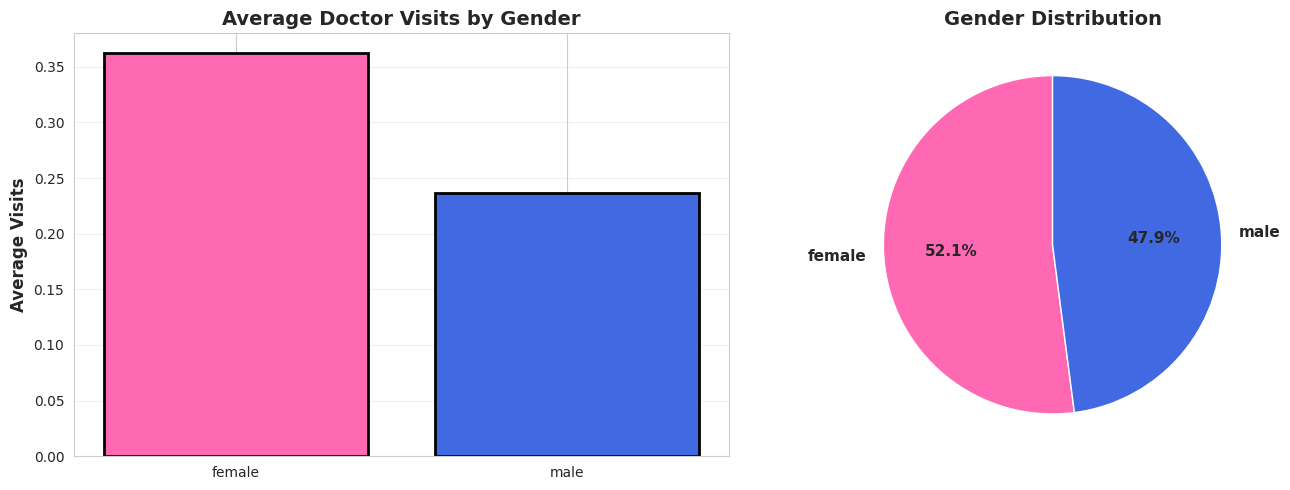

Average Visits by Gender:
gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


In [19]:
# ============================================
# STEP 5: CHART 2 - Visits by Gender
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_visits = df_clean.groupby('gender')['visits'].mean()
colors = ['#FF69B4', '#4169E1']

axes[0].bar(gender_visits.index, gender_visits.values, color=colors,
            edgecolor='black', linewidth=2)
axes[0].set_ylabel('Average Visits', fontsize=12, fontweight='bold')
axes[0].set_title('Average Doctor Visits by Gender', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

gender_count = df_clean['gender'].value_counts()
axes[1].pie(gender_count.values, labels=gender_count.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Gender Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_visits_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

print("Average Visits by Gender:")
print(gender_visits)

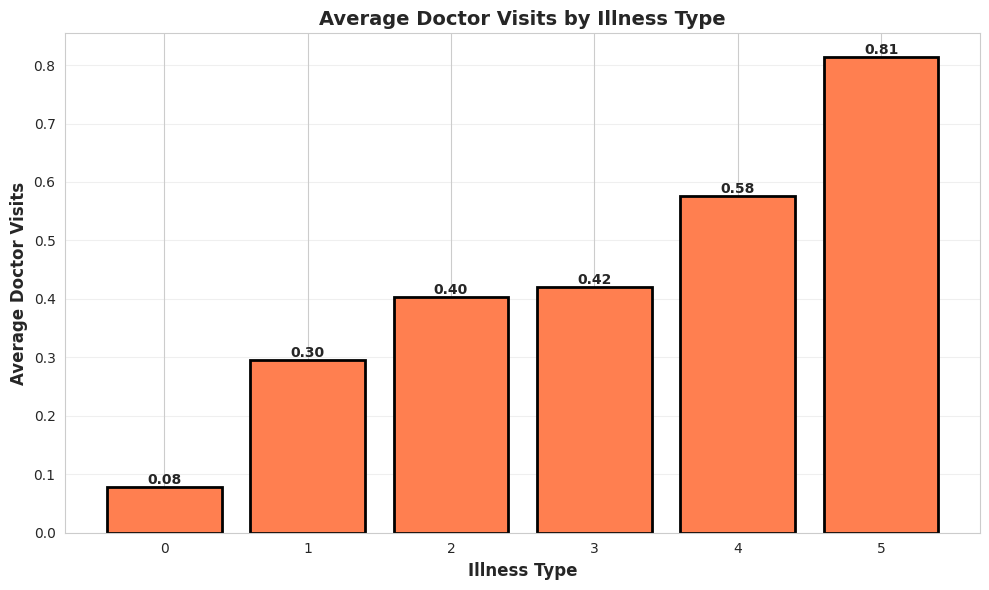

Illness Type wise Visits Summary:
             mean  count
illness                 
0        0.078507   1554
1        0.295482   1638
2        0.403805    946
3        0.420664    542
4        0.576642    274
5        0.813559    236


In [20]:
# ============================================
# STEP 6: CHART 3 - Illness Type vs Doctor Visits
# ============================================

illness_visits = df_clean.groupby('illness')['visits'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(illness_visits.index, illness_visits['mean'],
              color='coral', edgecolor='black', linewidth=2)

ax.set_xlabel('Illness Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Doctor Visits', fontsize=12, fontweight='bold')
ax.set_title('Average Doctor Visits by Illness Type', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(illness_visits.index)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_illness_type.png', dpi=300, bbox_inches='tight')
plt.show()

print("Illness Type wise Visits Summary:")
print(illness_visits)

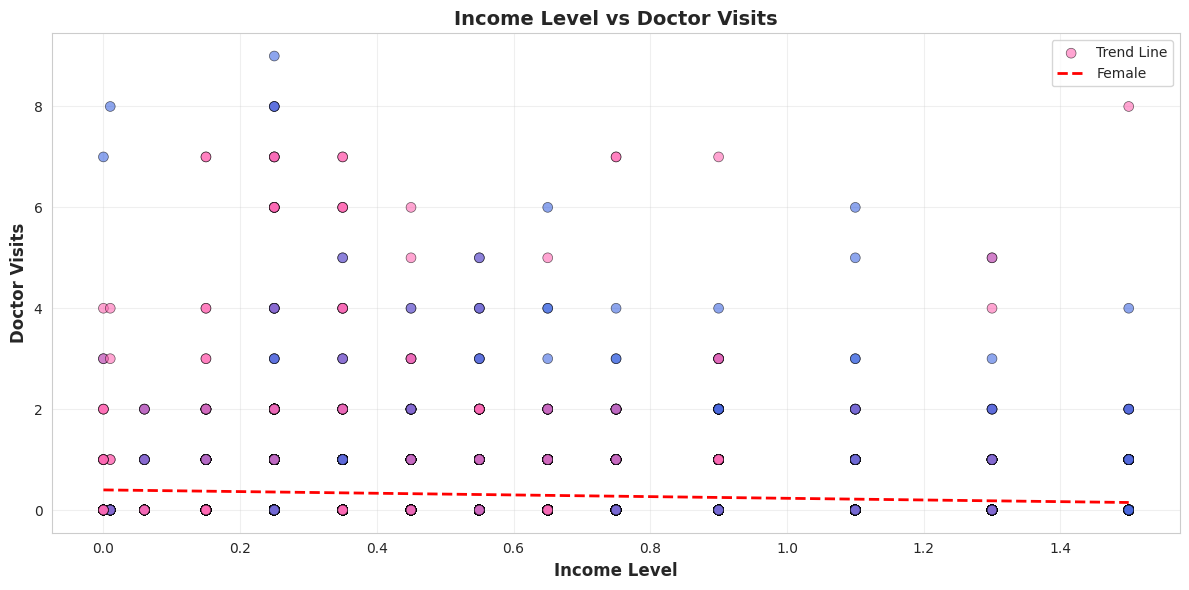

Correlation between Income and Visits: -0.077


In [21]:
# ============================================
# STEP 7: CHART 4 - Income vs Doctor Visits
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#FF69B4' if x == 'female' else '#4169E1' for x in df_clean['gender']]
ax.scatter(df_clean['income'], df_clean['visits'], alpha=0.6, s=50,
           c=colors, edgecolors='black', linewidth=0.5)

# Trend line
z = np.polyfit(df_clean['income'], df_clean['visits'], 1)
p = np.poly1d(z)
sorted_income = df_clean['income'].sort_values()
ax.plot(sorted_income, p(sorted_income), "r--", linewidth=2, label='Trend line')

ax.set_xlabel('Income Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Doctor Visits', fontsize=12, fontweight='bold')
ax.set_title('Income Level vs Doctor Visits', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(['Trend Line', 'Female', 'Male'], loc='upper right')

plt.tight_layout()
plt.savefig('chart4_income_vs_visits.png', dpi=300, bbox_inches='tight')
plt.show()

correlation = df_clean['income'].corr(df_clean['visits'])
print(f"Correlation between Income and Visits: {correlation:.3f}")

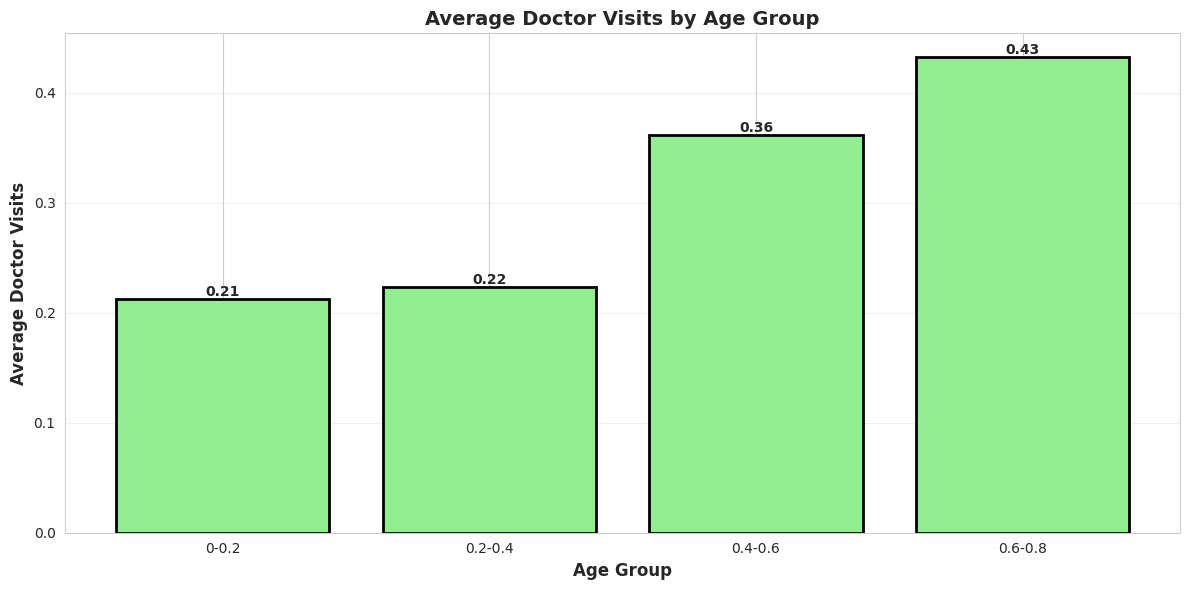

Age Group wise Average Visits:
age_group
0-0.2      0.212766
0.2-0.4    0.223546
0.4-0.6    0.361596
0.6-0.8    0.432209
Name: visits, dtype: float64


In [23]:
# ============================================
# STEP 8: CHART 5 - Age Groups vs Doctor Visits
# ============================================

# Age la groups madhe divide kara
df_clean['age_group'] = pd.cut(df_clean['age'],
                                 bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                 labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

age_visits = df_clean.groupby('age_group', observed=True)['visits'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(age_visits)), age_visits.values,
              color='lightgreen', edgecolor='black', linewidth=2)

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Doctor Visits', fontsize=12, fontweight='bold')
ax.set_title('Average Doctor Visits by Age Group', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(age_visits)))
ax.set_xticklabels(age_visits.index)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_age_groups.png', dpi=300, bbox_inches='tight')
plt.show()

print("Age Group wise Average Visits:")
print(age_visits)

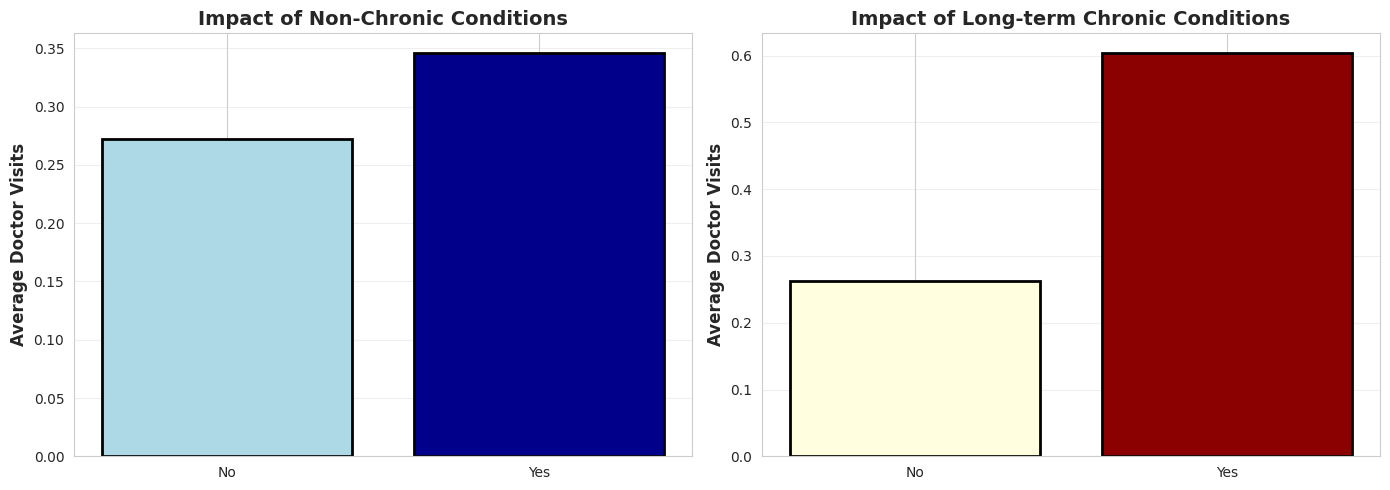

Non-Chronic: No=0.27, Yes=0.35
Long-term Chronic: No=0.26, Yes=0.60


In [24]:
# ============================================
# STEP 9: CHART 6 - Chronic Conditions Impact
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nchronic_visits = df_clean.groupby('nchronic')['visits'].mean()
lchronic_visits = df_clean.groupby('lchronic')['visits'].mean()

labels = ['No', 'Yes']

axes[0].bar(labels, nchronic_visits.values, color=['lightblue', 'darkblue'],
            edgecolor='black', linewidth=2)
axes[0].set_ylabel('Average Doctor Visits', fontsize=12, fontweight='bold')
axes[0].set_title('Impact of Non-Chronic Conditions', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(labels, lchronic_visits.values, color=['lightyellow', 'darkred'],
            edgecolor='black', linewidth=2)
axes[1].set_ylabel('Average Doctor Visits', fontsize=12, fontweight='bold')
axes[1].set_title('Impact of Long-term Chronic Conditions', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart6_chronic_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Non-Chronic: No={nchronic_visits[0]:.2f}, Yes={nchronic_visits[1]:.2f}")
print(f"Long-term Chronic: No={lchronic_visits[0]:.2f}, Yes={lchronic_visits[1]:.2f}")

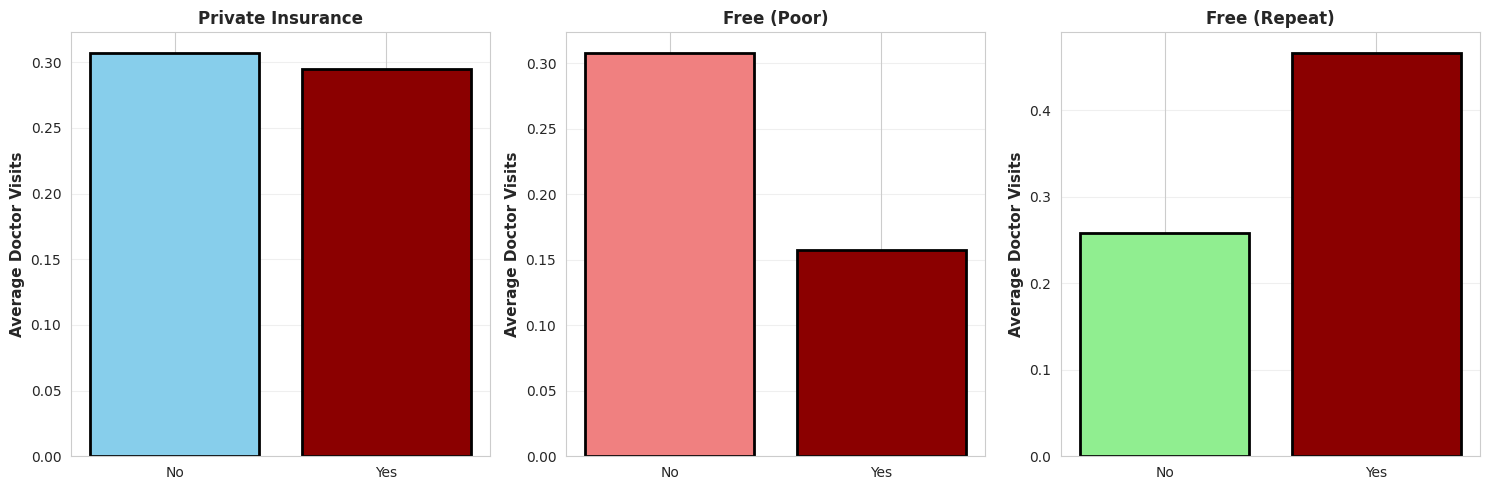

Insurance Type Impact Summary:

Private Insurance:
  No: 0.31, Yes: 0.29

Free (Poor):
  No: 0.31, Yes: 0.16

Free (Repeat):
  No: 0.26, Yes: 0.47


In [25]:
# ============================================
# STEP 10: CHART 7 - Insurance Type Impact
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

insurance_types = ['private', 'freepoor', 'freerepat']
insurance_labels = ['Private Insurance', 'Free (Poor)', 'Free (Repeat)']
colors_list = ['skyblue', 'lightcoral', 'lightgreen']

for idx, (col, label, color) in enumerate(zip(insurance_types, insurance_labels, colors_list)):
    visits_by_insurance = df_clean.groupby(col)['visits'].mean()
    axes[idx].bar(['No', 'Yes'], visits_by_insurance.values,
                  color=[color, 'darkred'], edgecolor='black', linewidth=2)
    axes[idx].set_ylabel('Average Doctor Visits', fontsize=11, fontweight='bold')
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart7_insurance_type.png', dpi=300, bbox_inches='tight')
plt.show()

print("Insurance Type Impact Summary:")
for col, label in zip(insurance_types, insurance_labels):
    visits_by_insurance = df_clean.groupby(col)['visits'].mean()
    print(f"\n{label}:")
    print(f"  No: {visits_by_insurance[0]:.2f}, Yes: {visits_by_insurance[1]:.2f}")

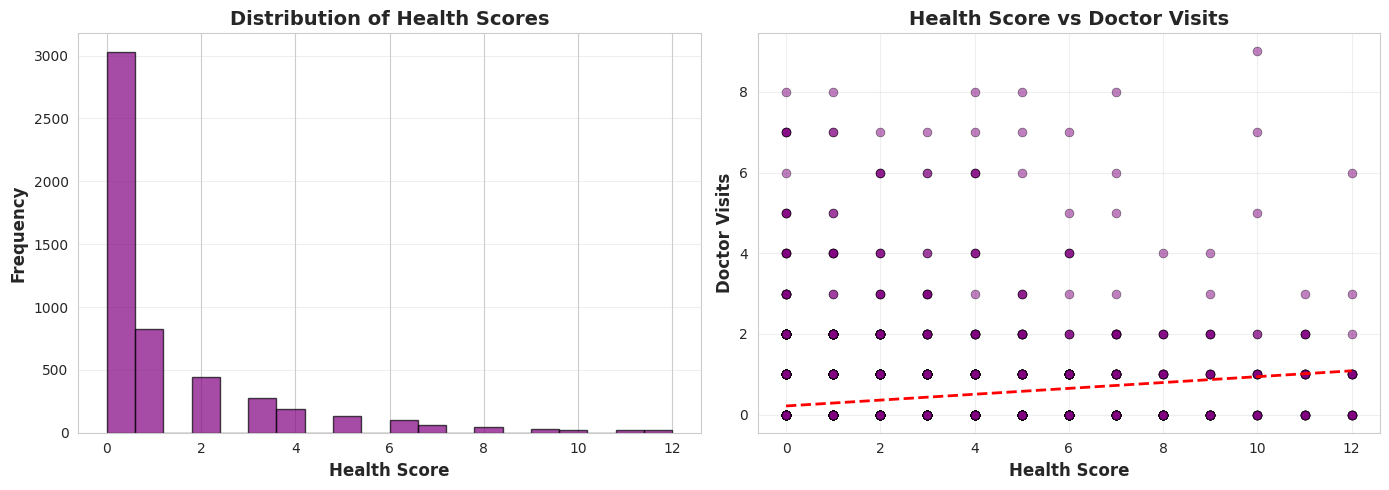

Correlation between Health and Visits: 0.193


In [26]:
# ============================================
# STEP 11: CHART 8 - Health Status Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of health scores
axes[0].hist(df_clean['health'], bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Health Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Health Scores', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Health vs Visits scatter
axes[1].scatter(df_clean['health'], df_clean['visits'], alpha=0.5, s=40,
                 color='purple', edgecolors='black', linewidth=0.5)
z = np.polyfit(df_clean['health'], df_clean['visits'], 1)
p = np.poly1d(z)
sorted_health = df_clean['health'].sort_values()
axes[1].plot(sorted_health, p(sorted_health), "r--", linewidth=2)
axes[1].set_xlabel('Health Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Doctor Visits', fontsize=12, fontweight='bold')
axes[1].set_title('Health Score vs Doctor Visits', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chart8_health_status.png', dpi=300, bbox_inches='tight')
plt.show()

health_correlation = df_clean['health'].corr(df_clean['visits'])
print(f"Correlation between Health and Visits: {health_correlation:.3f}")

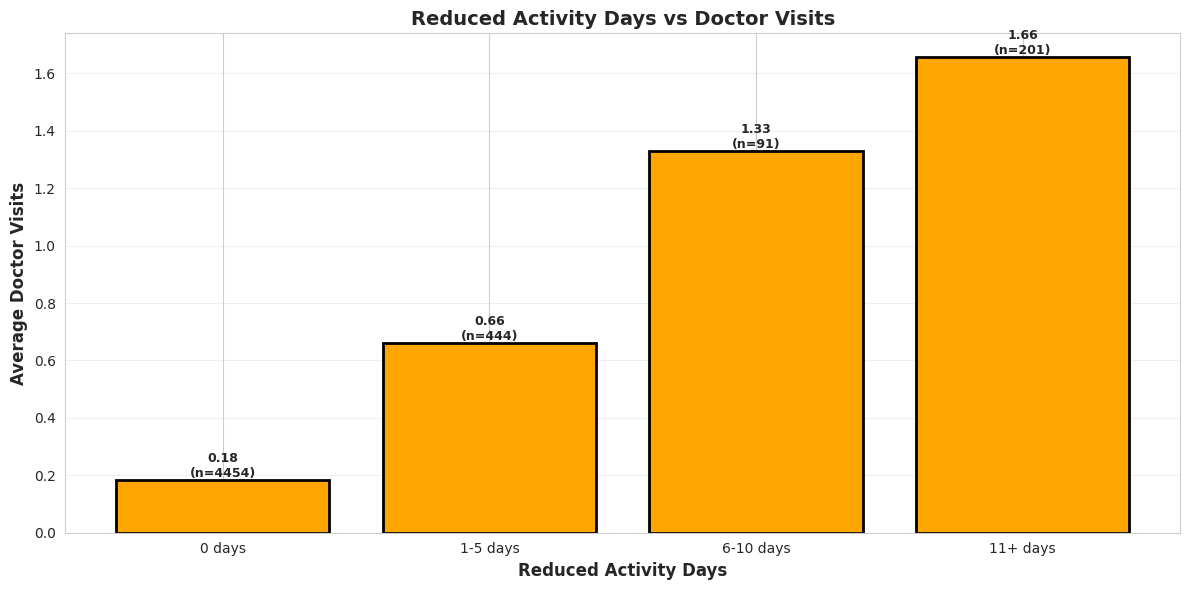

Reduced Activity Days wise Visits:
                   mean  count
reduced_group                 
0 days         0.183880   4454
1-5 days       0.659910    444
6-10 days      1.329670     91
11+ days       1.656716    201


In [27]:
# ============================================
# STEP 12: CHART 9 - Reduced Activity Days vs Visits
# ============================================

df_clean['reduced_group'] = pd.cut(df_clean['reduced'],
                                     bins=[-1, 0, 5, 10, 15],
                                     labels=['0 days', '1-5 days', '6-10 days', '11+ days'])

reduced_visits = df_clean.groupby('reduced_group', observed=True)['visits'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(reduced_visits)), reduced_visits['mean'],
              color='orange', edgecolor='black', linewidth=2)

ax.set_xlabel('Reduced Activity Days', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Doctor Visits', fontsize=12, fontweight='bold')
ax.set_title('Reduced Activity Days vs Doctor Visits', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(reduced_visits)))
ax.set_xticklabels(reduced_visits.index)
ax.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    count = reduced_visits['count'].iloc[i]
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}\n(n={int(count)})', ha='center', va='bottom',
            fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('chart9_reduced_activity.png', dpi=300, bbox_inches='tight')
plt.show()

print("Reduced Activity Days wise Visits:")
print(reduced_visits)

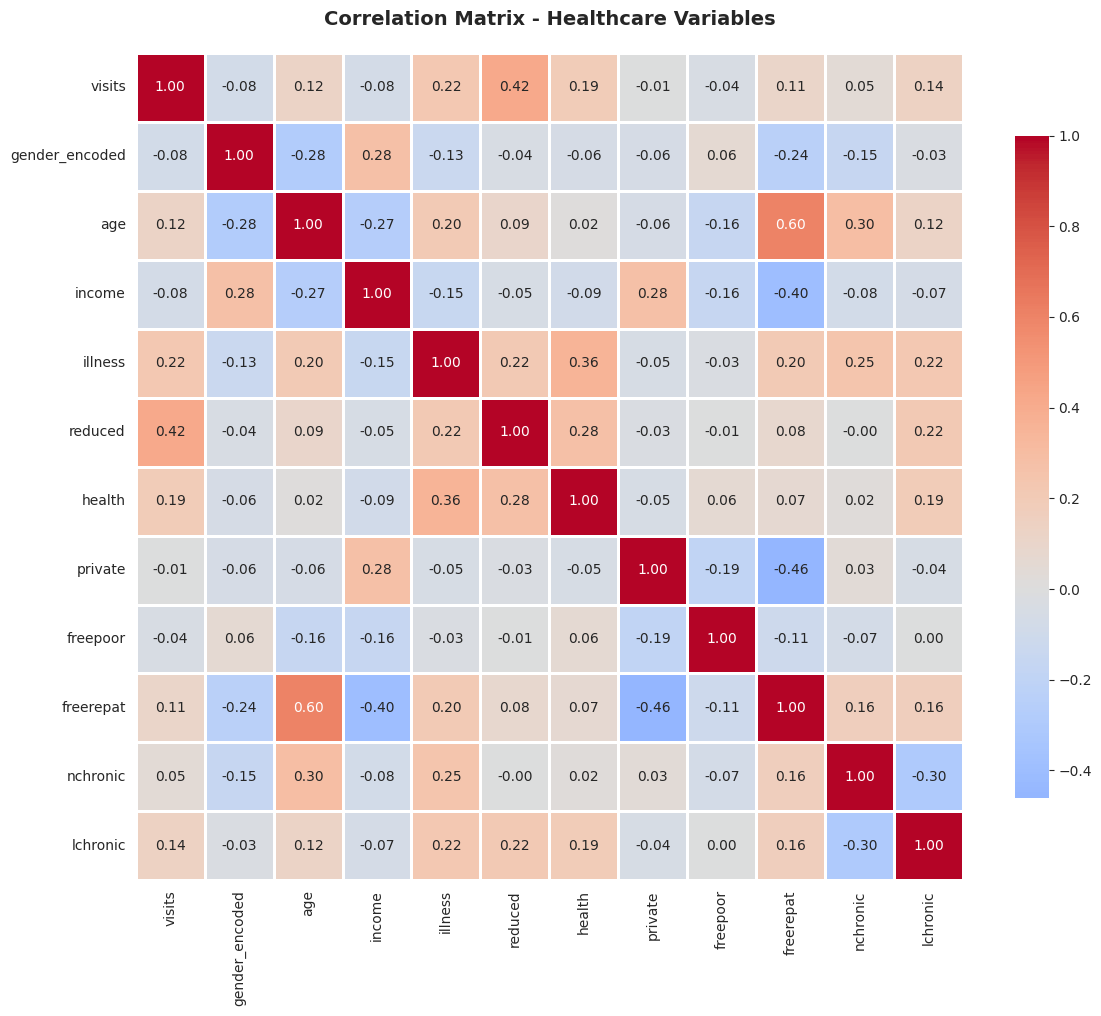

Top Correlations with Doctor Visits:
visits            1.000000
reduced           0.418954
illness           0.223552
health            0.193272
lchronic          0.137267
age               0.124537
freerepat         0.106543
nchronic          0.045171
private          -0.007964
freepoor         -0.038163
income           -0.076840
gender_encoded   -0.078637
Name: visits, dtype: float64


In [28]:
# ============================================
# STEP 13: CHART 10 - Correlation Heatmap
# ============================================

numerical_data = df_clean[['visits', 'gender_encoded', 'age', 'income', 'illness',
                            'reduced', 'health', 'private', 'freepoor', 'freerepat',
                            'nchronic', 'lchronic']]

correlation_matrix = numerical_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Healthcare Variables', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart10_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top Correlations with Doctor Visits:")
print(correlation_matrix['visits'].sort_values(ascending=False))

In [29]:
# ============================================
# STEP 14: KEY INSIGHTS & SUMMARY
# ============================================

print("=" * 60)
print("HEALTHCARE ANALYTICS - KEY INSIGHTS")
print("=" * 60)

# 1. Overall visits stats
print(f"\n1. Average Doctor Visits: {df_clean['visits'].mean():.2f}")
print(f"   Median Visits: {df_clean['visits'].median():.2f}")

# 2. Gender impact
gender_diff = df_clean.groupby('gender')['visits'].mean()
print(f"\n2. Gender Impact:")
print(f"   Female: {gender_diff.get('female', 0):.2f} visits")
print(f"   Male: {gender_diff.get('male', 0):.2f} visits")

# 3. Chronic conditions impact
lchronic_yes = df_clean[df_clean['lchronic'] == 1]['visits'].mean()
lchronic_no = df_clean[df_clean['lchronic'] == 0]['visits'].mean()
print(f"\n3. Long-term Chronic Condition Impact:")
print(f"   Without: {lchronic_no:.2f} visits")
print(f"   With: {lchronic_yes:.2f} visits")
print(f"   Increase: {((lchronic_yes/lchronic_no - 1)*100):.1f}%")

# 4. Health score correlation
health_corr = df_clean['health'].corr(df_clean['visits'])
print(f"\n4. Health Score Correlation: {health_corr:.3f}")
print(f"   (Negative = Lower health score → More visits)")

# 5. Reduced activity correlation
reduced_corr = df_clean['reduced'].corr(df_clean['visits'])
print(f"\n5. Reduced Activity Days Correlation: {reduced_corr:.3f}")
print(f"   (Positive = More reduced days → More visits)")

# 6. Highest illness type
max_illness = df_clean.groupby('illness')['visits'].mean().idxmax()
max_illness_val = df_clean.groupby('illness')['visits'].mean().max()
print(f"\n6. Highest Visit Illness Type: Type {int(max_illness)} ({max_illness_val:.2f} visits)")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("""
- Chronic conditions ani health status he sagyat mothe factors ahet
  je doctor visits vadhвतात.
- Reduced activity days pan strong indicator ahe.
- Insurance type ani income cha thoda weak effect distoy.
- Healthcare providers ni chronic patients var focus karayla have.
""")

HEALTHCARE ANALYTICS - KEY INSIGHTS

1. Average Doctor Visits: 0.30
   Median Visits: 0.00

2. Gender Impact:
   Female: 0.36 visits
   Male: 0.24 visits

3. Long-term Chronic Condition Impact:
   Without: 0.26 visits
   With: 0.60 visits
   Increase: 130.3%

4. Health Score Correlation: 0.193
   (Negative = Lower health score → More visits)

5. Reduced Activity Days Correlation: 0.419
   (Positive = More reduced days → More visits)

6. Highest Visit Illness Type: Type 5 (0.81 visits)

CONCLUSION

- Chronic conditions ani health status he sagyat mothe factors ahet
  je doctor visits vadhвतात.
- Reduced activity days pan strong indicator ahe.
- Insurance type ani income cha thoda weak effect distoy.
- Healthcare providers ni chronic patients var focus karayla have.



In [30]:
# ============================================
# STEP 15: Save Cleaned Dataset
# ============================================

df_clean.to_csv('Healthcare_Analytics_Cleaned.csv', index=False)

print("✅ Cleaned dataset saved as: Healthcare_Analytics_Cleaned.csv")
print(f"Total Records: {len(df_clean)}")
print(f"Total Columns: {len(df_clean.columns)}")

✅ Cleaned dataset saved as: Healthcare_Analytics_Cleaned.csv
Total Records: 5190
Total Columns: 15
